In [336]:
import numpy as np
import matplotlib
import pandas as pd
from matplotlib import pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

# Análise de Série Temporal

## Capítulo 1 - Introdução

### Operadores

O **operador de defasagem** é definido como:

$$B^m z_t = z_{t-m}$$

O **operador de avanço** (nome não confirmado) é definido como:

$$F^mz_t = B^{-m}z_t = z_{t+m}$$

O **operador de diferença de defasagem** é definido como:

$$\nabla z_t = z_t - z_{t-1} = (1-B)z_t$$


#### Propriedades dos operadores

1) O valor *i* pode ser qualquer inteiro
2) A defasagem de uma constante é a própria constante: $Bc = c$
3) Distributiva: $(B^i + B^j)z_t = B^iz_t + B^jz_t = z_{t-i} + z_{t-j}$
4) Associativa: $B^i B^jz_t = B^i (B^jz_t) = B^i z_{t-j} = z_{t-i-j}$



### Modelo de filtro linear

Nos modelos estocásticos, uma série temporal $z_t$ é entendida como gerada por uma série de "choques" independentes $a_t$. Esses choques são aleatórios, usualmente em distribuição normal com variância de $\sigma_a^2$. Essa sequência é chamada de processo de ruído branco.

$$z_t = \mu + a_t + \psi_1a_{t-1}+ \psi_2a_{t-2} + \cdots = \mu + \psi(B)a_t$$

$$\psi(B) = (1+\psi_1B+\psi_2B^2+\cdots)$$

### Modelo autorregressivo

O valor atual de uma série temporal pode escrito como uma combinação linear dos valores anteriores do processo e um choque $a_t$.

Dado uma série espaçada igualmente $z_t, z_{t-1}, z_{t-2}, \cdots$ e $\tilde{z}_t = z_t-\mu$.

O caso:

$$\tilde{z}_t = \phi_1 \tilde{z}_{t-1} + \phi_2 \tilde{z}_{t-2} + \cdots + \phi_p \tilde{z}_{t-p} + a_t$$

é um modelo autorregressivo de ordem p.

Podemos definir um operador autogressivo de ordem p:

$$\phi(B) = 1 - \phi_1B - \phi_2B^2 - \cdots - \phi_pB^p$$

$$\phi(B)\tilde{z}_t = a_t$$

$$\tilde{z}_t = \sum_{j=0}^\infty \phi^j a_{t-j}$$

O modelo autorregressivo é um caso particular do modelo linear. É possível verificar substituindo os termos sucessivamente:

$$\tilde{z}_t = \phi^{-1}(B)a_t = \psi(B)a_t$$

no qual $\psi_j = \phi^j$ dado que $\left|\phi\right|<1$. O valor $\phi$ vem do processo autorregressivo de primeira ordem $\tilde{z}_t = \phi \tilde{z}_{t-1} + a_t$.


O processo autorregressivo é considerado estacionário se os pesos $\phi_1, \phi_2, \cdots$ em $\psi(B) = \phi^{-1}(B)$ formarem uma série convergente. Desta forma, o operador $\phi(B) = 1 - \phi_1B - \phi_2B^2 - \cdots - \phi_pB^p$ define um polinômio em $B$ de grau $p$. Todas as suas raízes devem ter módulo maior que a unidade.

### Modelos de média móvel



## Capítulo 2 - Função de autocorrelação e espectro de processos estacionários

### Série temporal

Uma série temporal é definida a partir de observações em tempos discretos $\tau_1, \tau_2, \tau_3, \cdots, \tau_N$, escritas como $z(\tau_1), z(\tau_2), z(\tau_3), \cdots, z(\tau_N)$. Quando temos N valores sucessivos feitos em intervalos de tempo equidistantes $\tau_t = \tau_0 + th$, podemos escrever $z_1, z_2, z_3, \cdots, z_N$.

### Série determinística

Uma série é dita determinística quando seus valores podem ser expressos exatamente como uma função matemática

$z_t = cos(2\pi ft)$

### Processo Estocástico

Um processo é dito estocástico quando envolve alguma lei probabilística.

### Processo estocástico estacionário

Um processo é estacionário quando suas propriedades não dependem de uma variação do tempo de origem. Isto é, a distribuição de probabilidade de $m$ observações $z_{t_1}, z_{t_2}, \cdots, z_{t_m}$ associadas a $t_1, t_2, \cdots, t_m$ deve ser igual a $m$ observações $z_{t_1+k}, z_{t_2+k}, \cdots, z_{t_m+k}$ associadas a $t_1+k, t_2+k, \cdots, t_m+k$


#### Média e variância

Considerando um processo estacionário com $m=1$, isso significa que para qualquer instante de tempo $t$, a distribuição de probabilidade deve ser $p(z)$. Dessa forma, podemos definir a média e a variância:

$$\mu = E[z_t] = \int_{-\infty}^{\infty} zp(z)dz$$

$$\sigma_z^2 = E[(z_t-\mu)^2] = \int_{-\infty}^{\infty} (z-\mu)^2 p(z)dz$$

Lembrando que:

$$\int_{-\infty}^{\infty} p(z)dz = 1$$

Podemos estimar a média e a variância de um processo através de amostras, fazendo:

$$\bar{z} = \frac{1}{N}\sum_{t=1}^N z_t$$

$$\hat{\sigma}_z^2 = \frac{1}{N}\sum_{t=1}^N \left(z_t-\bar{z}\right)^2$$

#### Autocovariância e coeficientes de autocorrelação

A distribuição de probabilidade conjunta $p(z_{t_1},z_{t_2})$ deve ser a mesma para qualquer $t_1, t_2$ igualmente espaçados. A covariância entre dois valores $z_{t},z_{t+k}$ será chamada de **autocovariância** com atraso $k$:

$$\gamma_k = cov\left[z_{t},z_{t+k}\right] = E\left[(z_t-\mu)(z_{t+k}-\mu)\right]$$

A **autocorrelação** é dada por:

$$\rho_k = \frac{E\left[(z_t-\mu)(z_{t+k}-\mu)\right]}{\sqrt{E\left[(z_t-\mu)^2\right]E\left[(z_{t+k}-\mu)^2\right]}} = \frac{E\left[(z_t-\mu)(z_{t+k}-\mu)\right]}{\sigma_z^2} = \frac{\gamma_k}{\gamma_0} $$

Note que, como o processo é estacionário, a variância em $t$ deve ser igual àquela em $t+k$.


#### Matriz de autocovariância

A matriz de autocovariância $\mathbf{\Gamma}_n$ e a matriz de autocorrelação $\mathbf{P}_n$ de um processo com $n$ amostragens são dadas por:

$$\mathbf{\Gamma}_n = 
\begin{bmatrix}
\gamma_0 & \gamma_1 & \gamma_2 & \cdots & \gamma_{n-1}\\
\gamma_1 & \gamma_0 & \gamma_1 & \cdots & \gamma_{n-2}\\
\gamma_2 & \gamma_1 & \gamma_0 & \cdots & \gamma_{n-3}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
\gamma_{n-1} & \gamma_{n-2} & \gamma_{n-3} & \cdots & \gamma_0\\
\end{bmatrix}=
\sigma_z^2 \begin{bmatrix}
1 & \rho_1 & \rho_2 & \cdots & \rho_{n-1}\\
\rho_1 & 1 & \rho_1 & \cdots & \rho_{n-2}\\
\rho_2 & \rho_1 & 1 & \cdots & \rho_{n-3}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
\rho_{n-1} & \rho_{n-2} & \rho_{n-3} & \cdots & 1\\
\end{bmatrix} = 
\sigma_z^2 \mathbf{P}_n
$$

Dada uma função linear:

$$L_t = l_1 z_t + l_2 z_{t-1} + \cdots + l_n z_{t-n+1}$$

e dado que $cov[z_i,z_j] = \gamma_{|j-1|}$, então a variância de L_t é:

$$var[L_t] = \sum_{i=1}^n \sum_{j=1}^n l_il_j\gamma_{|j-1|}$$

Lembrando que a variância de uma soma é dada por:

$$var[aX+bY] = a^2var[X] + b^2var[Y] + 2ab \,cov[X,Y]$$

Para qualquer combinação de l's, tal que pelo menos um deles não seja zero, essa expressão deve ser positiva. Consequentemente, as matrizes de autocorrelação e autocovariância devem ser positivo-definidas.


## Capítulo 3 - Modelos estacionários lineares

Conforme citado no Capítulo 1, um processo estocástico derivado de um filtro linear pode ser representado através de ruídos brancos $a_t$ através de:

$$\tilde{z}_t = a_t + \psi_1a_{t-1}+ \psi_2a_{t-2} + \cdots = \psi(B)a_t$$

No qual $\tilde{z}_t = z_t-\mu$.

$$\psi(B) = (1+\psi_1B+\psi_2B^2+\cdots)$$

Como as variáveis aleatórias $a_t$ são consideradas independentes:

$$E[a_t] = 0$$
$$var[a_t] = \sigma_a^2$$
$$\gamma_k = covar[a_t,a_{t+k}] = \delta_{k} \sigma_a^2$$
$$\rho_k = \delta_{k}$$

De acordo com Wold [311 (seguindo a ref do Box)], $\sum_{j=0}^{\infty} \psi_j^2 < \infty$ para qualquer processo não determinístico estacionário com média não nula. Desta forma, podemos escrever:

$$\tilde{z}_t = a_t + \pi_1\tilde{z}_{t-1}+ \pi_2\tilde{z}_{t-2} + \cdots$$

### Relação entre $\pi$ e $\psi$

Considerando o modelo abaixo como exemplo:

$$\tilde{z} = a_t - \theta a_{t-1} = (1-\theta B)a_t = \psi(B)a_t = (1+\psi_1B+\psi_2B^2+\cdots)a_t$$

Desta forma:

$$(1-\theta B)^{-1}\tilde{z}_t  = a_t$$

A soma de uma série geométrica infinita é dada por:

$$\sum_{t=0}^\infty r^t = (1-r)^{-1}$$

Desta forma:

$$(1+\theta B+\theta^2 B^2+\theta^3 B^3+\cdots)\tilde{z}_t  = a_t$$

$$\tilde{z}_t = -\theta \tilde{z}_{t-1} -\theta^2 \tilde{z}_{t-2} -\theta^3 \tilde{z}_{t-3}-\cdots + a_t$$

Portanto, para este caso $\pi_j = -\theta^j$.

Em um caso geral, o modelo é descrito por:

$$\tilde{z}_t = \left(1+\sum\limits_{j=1}^\infty \psi_jB^j\right)a_t= \psi(B)a_t$$

$$\pi(B)\tilde{z}_t = \left(1-\sum\limits_{j=1}^\infty \pi_jB^j\right)\tilde{z}_t = a_t$$

Usando as duas expressões:

$$\psi(B)\pi(B)\tilde{z}_t = \psi(B)a_t = \tilde{z}_t$$

Portanto:

$$\psi(B)\pi(B)= 1$$
$$\pi(B)= \psi(B)^{-1}$$

### Processo autorregressivo (AR)

Um processo no qual apenas os p primeiros pesos são não nulos:

$$\tilde{z}_t = a_t + \phi_1\tilde{z}_{t-1}+ \phi_2\tilde{z}_{t-2} + \cdots+ \phi_p\tilde{z}_{t-p}$$

é um modelo autorregressivo de ordem p.

### Processo média móvel (MA)

Um processo no qual apenas os primeiros q pesos são não nulos:

$$\tilde{z}_t = a_t - \theta_1a_{t-1} - \theta_2a_{t-2} - \cdots - \theta_qa_{t-q}$$

### Processo misto autorregressivo-média móvel (ARMA)

É um processo que combina AR e MA:

$$\tilde{z}_t = a_t + \phi_1\tilde{z}_{t-1}+ \phi_2\tilde{z}_{t-2} + \cdots+ \phi_p\tilde{z}_{t-p} - \theta_1a_{t-1} - \theta_2a_{t-2} - \cdots - \theta_qa_{t-q}$$

$$\tilde{z}_t = \frac{\theta(B)}{\phi(B)}a_t =\frac{1-\theta_1 B - \cdots - \theta_q B^q}{1-\phi_1 B - \cdots - \phi_q B^q} a_t$$

que também pode ser expressado como:

$$\phi(B)z_t = \theta_0 + \theta(B)a_t$$

$$\theta_0 = \left(1-\phi_1-\phi_2-\cdots-\phi_p\right)\mu$$

### Propriedades de um AR

#### Estacionariedade

$$\tilde{z}_t = a_t + \phi_1\tilde{z}_{t-1}+ \phi_2\tilde{z}_{t-2} + \cdots+ \phi_p\tilde{z}_{t-p}$$
$$\tilde{z}_t = \phi^{-1}(B)a_t \equiv \psi(B) a_t = \sum\limits_{j=0}^\infty \psi_ja_{t-j}$$

Se a expressão do lado direito for convergente, então:

$$\phi(B) = \left(1-G_1B\right)\left(1-G_2B\right)\cdots\left(1-G_pB\right)$$

Com $G_1^{-1}\cdots G_p^{-1}$ sendo as raizes de $\phi(B)=0$, portanto:

$$\tilde{z}_t = \phi^{-1}(B)a_t = \sum\limits_{i=1}^p  \frac{K_i}{1-G_iB} a_{t}$$

Portanto, $\psi(B) = \phi^{-1}(B)$ é uma série convergente com $\left|B\right| \leq 1$, isto é, as raízes de $\phi(B)=0$ (polinômio característico) devem estar fora do círculo unitário. Outra interpretação é com as raízes em $m$:

$$m^p - \phi_1 m^{p-1} - \cdots - \phi_p = 0$$

No qual as raízes devem ser $m_1 = G_1 ,\cdots, m_p = G_p$. Assim, todas as raízes devem estar dentro do círculo unitário.


# Test data

In [68]:
# Generating data

def generate_data(mean, std, num_samples):
    data = np.random.normal(scale=std,size=num_samples)
    data = data-np.mean(data)
    data = data * (std/np.std(data))
    data = data + mean
    return data


std = 1
mean = 0
size = 10
num_samples = 24*30

data = np.array([generate_data(mean,std,num_samples) for _ in range(size)])


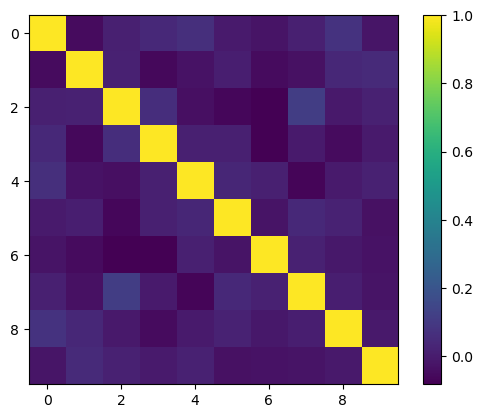

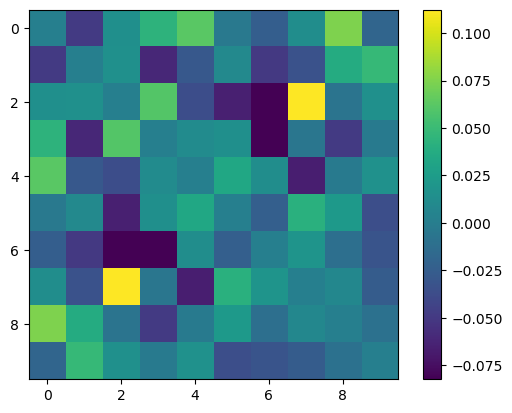

In [69]:
covar = np.cov(data)

plt.figure(1)
plt.imshow(covar)
plt.colorbar()

covar = np.cov(data) - np.eye(size)

plt.figure(2)
plt.imshow(covar)
plt.colorbar()

In [341]:
N = 800
zt = np.zeros(N)


mu = 0
sigma = 1

d = 1
CAR = [0.4,0.4,0.13]
CMA = [0.3]

ord = (len(CAR),d,len(CMA))

mod = sm.tsa.SARIMAX(zt,order=ord,trend='c',)

sim = mod.simulate([mu,*CAR,*CMA,sigma],N)
diff1 = np.diff(sim)
diff2 = np.diff(diff1)

part = int(np.floor(N*0.8))
sim_train = sim[:part]
sim_test = sim[part:]

plt.figure(1)
plt.plot(np.arange(0,sim_train.size),sim_train,'b-')
plt.plot(np.arange(sim_train.size,sim.size),sim_test,'r-')
#plt.figure(2)
#plt.plot(diff1)
#plt.figure(3)
#plt.plot(diff2)

res = adfuller(sim,autolag='AIC')
print(res[1])

TypeError: unsupported operand type(s) for -: 'int' and 'str'

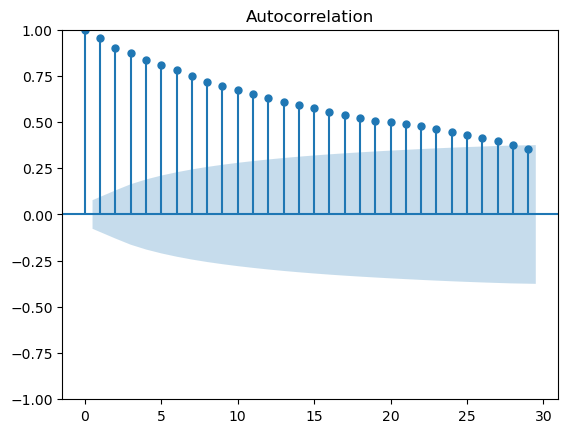

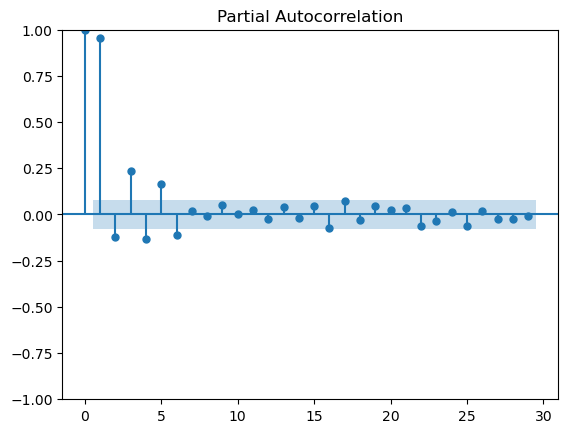

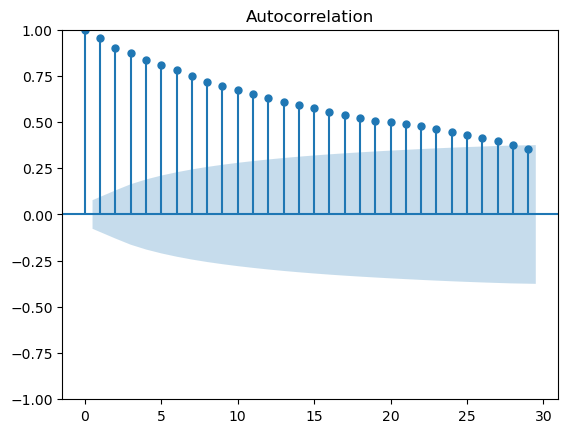

In [206]:
plot_pacf(sim_train)
plot_acf(sim_train)

In [6]:
sm.stats.diagnostic.acorr_ljungbox(sim,boxpierce=True)

,lb_stat,lb_pvalue,bp_stat,bp_pvalue
1,144.812156,2.360633e-33,143.946745,3.649507e-33
2,228.996162,1.879816e-50,227.459962,4.052256e-50
3,255.573216,4.077260e-55,253.772304,9.997877e-55
4,279.447971,2.930976e-59,277.361703,8.256734e-59
5,286.844836,6.733776e-60,284.655425,1.989421e-59
6,289.661920,1.340921e-59,287.427615,4.035498e-59
7,291.529533,3.892087e-59,289.261745,1.186332e-58
8,291.918469,2.158788e-58,289.642933,6.579773e-58
9,292.886142,8.418048e-58,290.589402,2.582607e-57
10,293.596973,3.506036e-57,291.283242,1.080408e-56


In [54]:
# pmdarima
import pmdarima
from pmdarima import ARIMA
from pmdarima import auto_arima

In [333]:
print(ord)
model = auto_arima(
            y                 = sim_train,
            start_p           = 3,
            start_q           = 0,
            max_p             = 5,
            max_q             = 5,
            seasonal          = True,
            m                 = 24,
            test              = 'adf',
            d                 = 1, # The algorithm will determine 'd'
            D                 = 1,
            trace             = True,
        )

(3, 1, 1)
Performing stepwise search to minimize aic
 ARIMA(3,1,0)(1,1,1)[24]             : AIC=inf, Time=19.04 sec
 ARIMA(0,1,0)(0,1,0)[24]             : AIC=3027.471, Time=0.14 sec
 ARIMA(1,1,0)(1,1,0)[24]             : AIC=2008.315, Time=1.00 sec
 ARIMA(0,1,1)(0,1,1)[24]             : AIC=2408.657, Time=2.89 sec
 ARIMA(1,1,0)(0,1,0)[24]             : AIC=2192.207, Time=0.25 sec
 ARIMA(1,1,0)(2,1,0)[24]             : AIC=1964.046, Time=4.15 sec
 ARIMA(1,1,0)(2,1,1)[24]             : AIC=inf, Time=50.08 sec
 ARIMA(1,1,0)(1,1,1)[24]             : AIC=inf, Time=7.58 sec
 ARIMA(0,1,0)(2,1,0)[24]             : AIC=2882.450, Time=2.12 sec
 ARIMA(2,1,0)(2,1,0)[24]             : AIC=1936.156, Time=5.92 sec
 ARIMA(2,1,0)(1,1,0)[24]             : AIC=1975.215, Time=2.11 sec
 ARIMA(2,1,0)(2,1,1)[24]             : AIC=inf, Time=58.79 sec
 ARIMA(2,1,0)(1,1,1)[24]             : AIC=inf, Time=14.20 sec
 ARIMA(3,1,0)(2,1,0)[24]             : AIC=1931.831, Time=6.17 sec
 ARIMA(3,1,0)(1,1,0)[24]      

In [306]:
print(CAR)
print(CMA)

print(model.summary())

[0.4, 0.4, 0.13]
[0.3]
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  640
Model:               SARIMAX(3, 1, 0)   Log Likelihood                -900.497
Date:                Wed, 04 Sep 2024   AIC                           1808.994
Time:                        12:26:46   BIC                           1826.833
Sample:                             0   HQIC                          1815.919
                                - 640                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6996      0.041     16.951      0.000       0.619       0.781
ar.L2          0.1868      0.049      3.787      0.000       0.090       0.284
ar.L3          0.0657      0.

In [295]:
#ord = (4,1,3)

mod = ARIMA(order=ord,enforce_stationarity=False,enforce_invertibility=False)
#mod = sm.tsa.SARIMAX(endog=sim,order=(1,0,1),trend='c').fit(disp=0)
res = mod.fit(sim_train,disp=0)
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  640
Model:               SARIMAX(3, 1, 1)   Log Likelihood                -895.242
Date:                Wed, 04 Sep 2024   AIC                           1802.484
Time:                        12:25:44   BIC                           1829.216
Sample:                             0   HQIC                          1812.863
                                - 640                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0210      0.038      0.556      0.578      -0.053       0.095
ar.L1          0.8033      0.576      1.396      0.163      -0.325       1.931
ar.L2          0.1151      0.409      0.281      0.779      -0.687       0.918
ar.L3          0.0396      0.144      0.275      0.784      -0.243       0.322
ma.L1         -0.1034      0.574     -0.180      0.857      -1.228       1.021
sigma2         0.9776      0.060     16.307      0.000       0.860       1.095
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 2.57
Prob(Q):                              0.99   Prob(JB):                         0.28
Heteroskedasticity (H):               0.96   Skew:                             0.01
Prob(H) (two-sided):                  0.75   Kurtosis:                         2.69
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

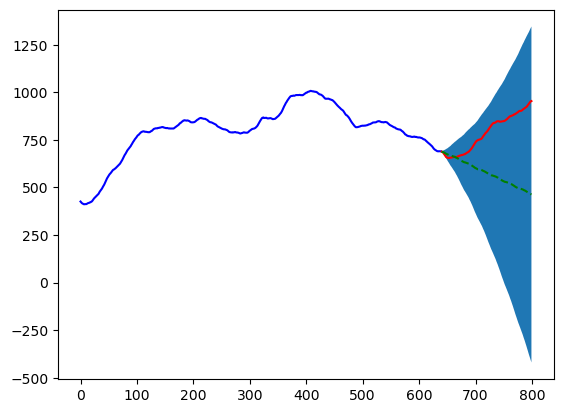

In [334]:
fitted, confint = model.predict(n_periods=sim_test.size, return_conf_int=True)

plt.plot(np.arange(0,sim_train.size),sim_train,'b-')
plt.plot(np.arange(sim_train.size,sim.size),sim_test,'r-')
plt.plot(np.arange(sim_train.size,sim.size),fitted,'g--')

plt.fill_between(np.arange(sim_train.size,sim.size),confint[:,0],confint[:,1])

In [344]:

df = pd.read_csv('./Programs/AirPassengers.csv')

df['Month'] = pd.to_datetime(df['Month'], infer_datetime_format=True)
df = df.set_index(['Month'])


df['#Passengers_diff'] = df['#Passengers'].diff(periods=12)
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   #Passengers       144 non-null    int64  
 1   #Passengers_diff  132 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 3.4 KB


/tmp/ipykernel_73078/2229067612.py:3: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['Month'] = pd.to_datetime(df['Month'], infer_datetime_format=True)


In [345]:
df['#Passengers_diff'].fillna(method='backfill', inplace=True)

/tmp/ipykernel_73078/2287783042.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['#Passengers_diff'].fillna(method='backfill', inplace=True)


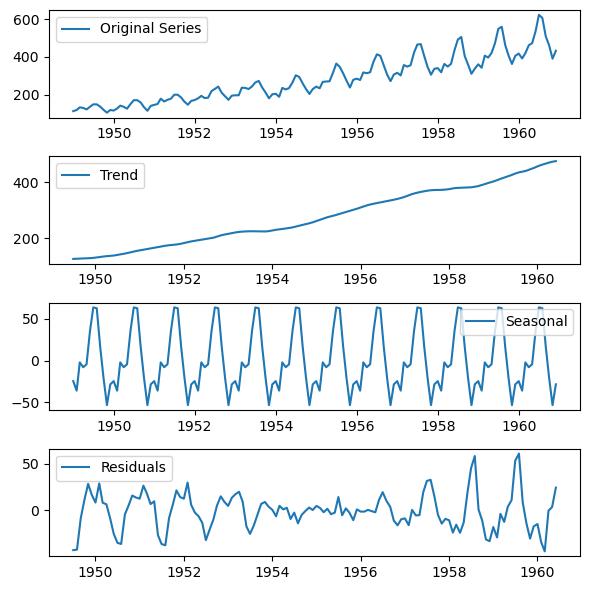

In [348]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df['#Passengers'], model='additive', period=12)
trend = result.trend.dropna()
seasonal = result.seasonal.dropna()
residual = result.resid.dropna()
 
# Plot the decomposed components
plt.figure(figsize=(6,6))
 
plt.subplot(4, 1, 1)
plt.plot(df['#Passengers'], label='Original Series')
plt.legend()
 
plt.subplot(4, 1, 2)
plt.plot(trend, label='Trend')
plt.legend()
 
plt.subplot(4, 1, 3)
plt.plot(seasonal, label='Seasonal')
plt.legend()
 
plt.subplot(4, 1, 4)
plt.plot(residual, label='Residuals')
plt.legend()
 
plt.tight_layout()
plt.show()

In [353]:

df['month_index'] = df.index.month

In [363]:

def sarimax_forecast(SARIMAX_model, periods=24):
    # Forecast
    n_periods = periods
 
    forecast_df = pd.DataFrame({"month_index": pd.date_range(df.index[-1], periods=n_periods, freq='MS').month},
                               index=pd.date_range(df.index[-1] + pd.DateOffset(months=1), periods=n_periods, freq='MS'))
 
    fitted, confint = SARIMAX_model.predict(n_periods=n_periods,
                                            return_conf_int=True,
                                            exogenous=forecast_df[['month_index']])
    index_of_fc = pd.date_range(df.index[-1] + pd.DateOffset(months=1), periods=n_periods, freq='MS')
 
    # make series for plotting purpose
    fitted_series = pd.Series(fitted, index=index_of_fc)
    lower_series = pd.Series(confint[:, 0], index=index_of_fc)
    upper_series = pd.Series(confint[:, 1], index=index_of_fc)
 
    # Plot
    plt.figure(figsize=(15, 7))
    plt.plot(df["#Passengers"], color='#1f76b4')
    plt.plot(fitted_series, color='darkgreen')
    plt.fill_between(lower_series.index,
                     lower_series,
                     upper_series,
                     color='k', alpha=.15)
 
    plt.title("SARIMAX - Forecast")
    plt.show()

In [355]:
import pmdarima as pm
SARIMAX_model = pm.auto_arima(df[['#Passengers']], exogenous=df[['month_index']],
                           start_p=1, start_q=1,
                           test='adf',
                           max_p=3, max_q=3, m=12,
                           start_P=0, seasonal=True,
                           d=None, D=1,
                           trace=False,
                           error_action='ignore',
                           suppress_warnings=True,
                           stepwise=True)

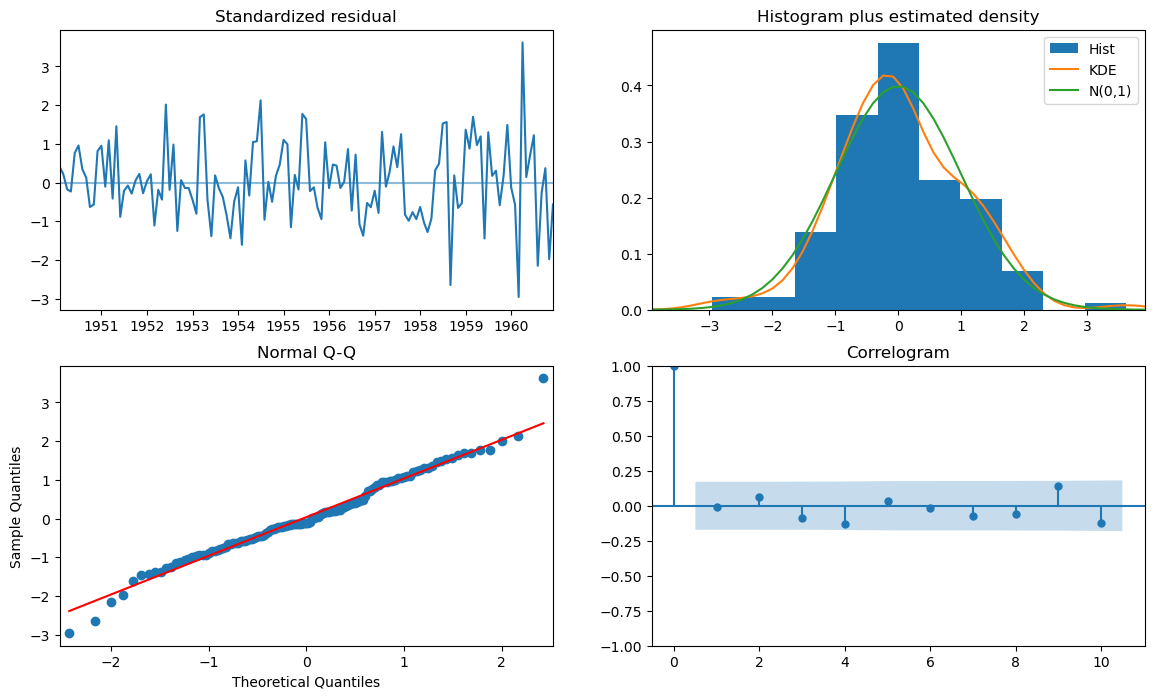

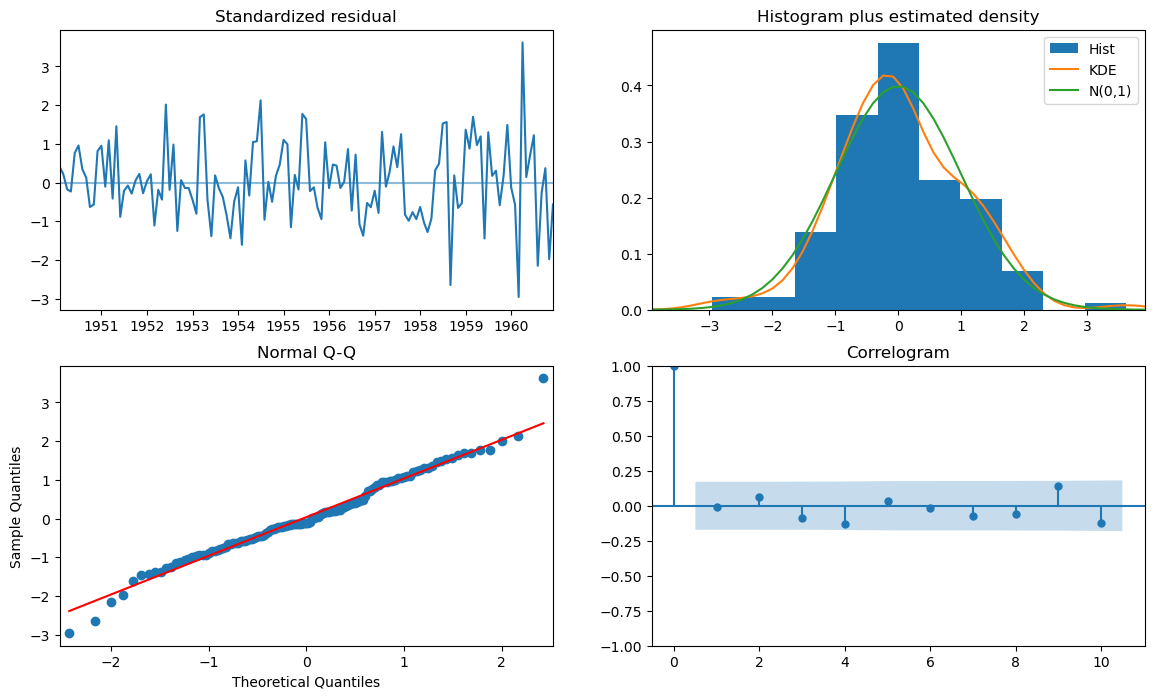

In [366]:
SARIMAX_model.plot_diagnostics(figsize=(14,8))

In [367]:
SARIMAX_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                  144
Model:             SARIMAX(0, 1, 1)x(2, 1, [], 12)   Log Likelihood                -505.589
Date:                             Wed, 04 Sep 2024   AIC                           1019.178
Time:                                     15:38:49   BIC                           1030.679
Sample:                                 01-01-1949   HQIC                          1023.851
                                      - 12-01-1960                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3634      0.074     -4.945      0.000      -0.508      -0.219
ar.S.L12      -0.1239      0.090     -1.372      0.170      -0.301       0.053
ar.S.L24       0.1911      0.107      1.783      0.075      -0.019       0.401
sigma2       130.4480     15.527      8.402      0.000     100.016     160.880
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 4.59
Prob(Q):                              0.92   Prob(JB):                         0.10
Heteroskedasticity (H):               2.70   Skew:                             0.15
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.87
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

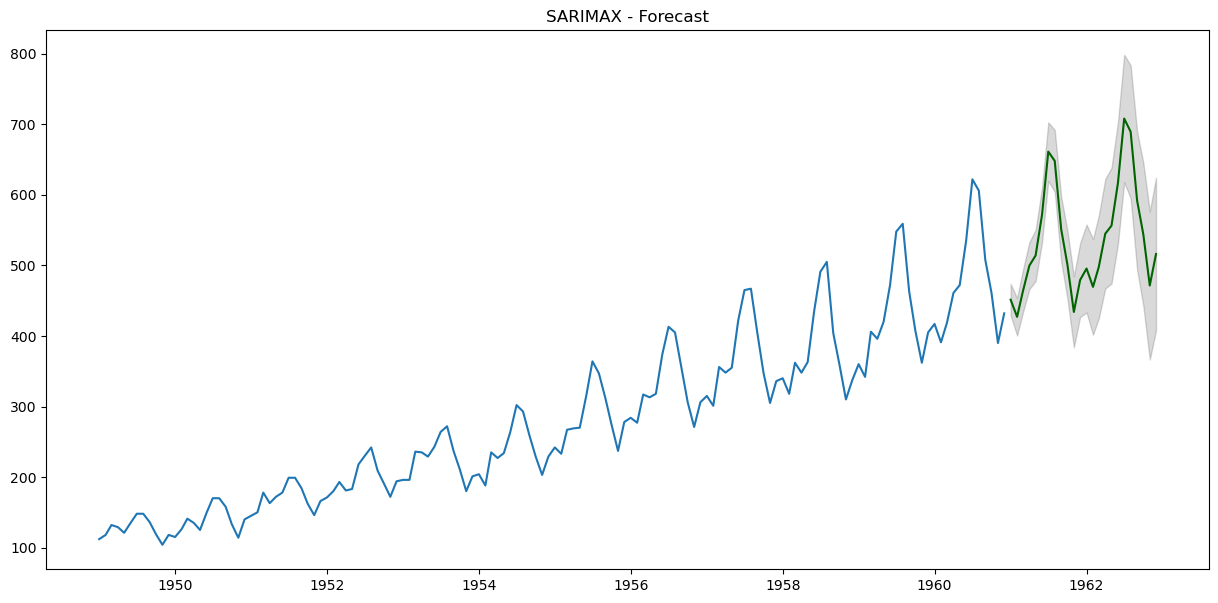

In [364]:

sarimax_forecast(SARIMAX_model, periods=24)